In [ ]:
import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")

print("Dataset downloaded to:", path)

# List files inside the dataset folder
print(os.listdir(path))

df = pd.read_csv(os.path.join(path, "US_Accidents_March23.csv"))

df = df[df["State"] == "CA"]
df.head()

Using Colab cache for faster access to the 'us-accidents' dataset.
Dataset downloaded to: /kaggle/input/us-accidents
['US_Accidents_March23.csv']


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
728,A-729,Source2,3,2016-06-21 10:34:40,2016-06-21 11:04:40,38.085300,-122.233017,NaN,NaN,0.0,...,False,False,False,False,False,False,Day,Day,Day,Day
729,A-730,Source2,3,2016-06-21 10:30:16,2016-06-21 11:16:39,37.631813,-122.084167,NaN,NaN,0.0,...,False,False,False,False,False,False,Day,Day,Day,Day
730,A-731,Source2,2,2016-06-21 10:49:14,2016-06-21 11:19:14,37.896564,-122.070717,NaN,NaN,0.0,...,False,False,False,False,False,False,Day,Day,Day,Day
731,A-732,Source2,3,2016-06-21 10:41:42,2016-06-21 11:11:42,37.334255,-122.032471,NaN,NaN,0.0,...,False,False,False,False,False,False,Day,Day,Day,Day
732,A-733,Source2,2,2016-06-21 10:16:26,2016-06-21 11:04:16,37.250729,-121.910713,NaN,NaN,0.0,...,False,False,False,False,False,False,Day,Day,Day,Day


In [ ]:
df["Weather_Condition"] = df["Weather_Condition"].fillna("Missing")
df["Temperature(F)"] = df["Temperature(F)"].fillna(0)
df["Visibility(mi)"] = df["Visibility(mi)"].fillna(0)
df["Wind_Speed(mph)"] = df["Wind_Speed(mph)"].fillna(0)
df["Precipitation(in)"] = df["Precipitation(in)"].fillna(0)
df.isna().sum()

CLEAR = {"Clear", "Fair"}

CLOUDY = {"Partly Cloudy", "Mostly Cloudy", "Overcast", "Scattered Clouds", "Cloudy"}

RAIN = {
    "Rain", "Light Rain", "Heavy Rain",
    "Light Drizzle", "Drizzle", "Heavy Drizzle",
    "Rain Showers", "Rain Shower", "Light Rain Showers", "Light Rain Shower",
    "Showers in the Vicinity",
    "Light Rain with Thunder",
    "Thunderstorms and Rain", "Light Thunderstorms and Rain", "Heavy Thunderstorms and Rain",
    "Thunderstorm", "Light Thunderstorm", "T-Storm", "Heavy T-Storm",
    "Thunder in the Vicinity", "Thunder",
    "Heavy Rain Shower", "Rain Shower / Windy", "Light Rain Shower / Windy",
    "Light Rain / Windy", "Rain / Windy", "Heavy Rain / Windy", 'Heavy T-Storm / Windy',
    'T-Storm / Windy', 'Thunder / Windy'
}

SNOW = {
    "Snow", "Light Snow", "Heavy Snow",
    "Light Snow Showers", "Light Snow Shower",
    "Blowing Snow",
    "Wintry Mix", "Wintry Mix / Windy",
    "Light Freezing Rain",
    "Snow / Windy", "Light Snow / Windy", "Heavy Snow / Windy",
    "Snow and Thunder", "Light Snow with Thunder"
}

LOW_VIS = {
    "Fog", "Patches of Fog", "Shallow Fog", "Partial Fog", "Light Freezing Fog",
    "Mist", "Haze", "Light Haze",
    "Smoke", "Heavy Smoke",
    "Fog / Windy", "Mist / Windy", "Haze / Windy", "Smoke / Windy"
}

DUST = {
    "Blowing Sand", "Blowing Dust", "Blowing Dust / Windy",
    "Widespread Dust", "Widespread Dust / Windy",
    "Duststorm", "Dust Whirls",
    "Sand / Windy",
    "Volcanic Ash"
}

HAIL = {"Hail", "Small Hail", "Light Hail", "Thunder and Hail"}

WINDY = {
    "Fair / Windy",
    "Partly Cloudy / Windy", "Mostly Cloudy / Windy", "Cloudy / Windy",
    "Squalls", "Squalls / Windy",
    "Drizzle / Windy", "Light Drizzle / Windy"
}


# Step 2: function to map weather → group
def weather_group(w):

    if w in CLEAR:
        return "Clear"

    elif w in CLOUDY:
        return "Cloudy"

    elif w in RAIN:
        return "Rain"

    elif w in SNOW:
        return "Snow"

    elif w in LOW_VIS:
        return "Low Visibility"

    elif w in DUST:
        return "Dust"

    elif w in HAIL:
        return "Hail"

    elif w in WINDY:
        return "Windy"

    else:
        return "Other"


# Step 3: create new column in dataframe
df["Weather_Group"] = df["Weather_Condition"].apply(weather_group)


In [ ]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from itertools import combinations
df["Severe"] = (df["Severity"] >= 3).astype(int)
cat_features = ["Weather_Group"]
infra_features = [
    "Bump","Crossing","Give_Way","Junction","Railway",
    "Roundabout","Stop","Traffic_Signal",
    "Traffic_Calming","Turning_Loop"
]
quant_features = [
    "Temperature(F)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)"
]
candidate_features = cat_features + infra_features + quant_features

ct = make_column_transformer(
    (StandardScaler(), quant_features),
    (OneHotEncoder(handle_unknown="ignore"), cat_features),
    remainder="passthrough"
)

pipeline = make_pipeline(
    ct,
    LogisticRegression(solver="saga", max_iter=1000) #to reduce runtime
)

df_sample = df.sample(500000, random_state=1)

scores = cross_val_score(
    pipeline,
    df_sample[candidate_features],
    df_sample["Severe"],
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

scores.mean()

np.float64(0.8367279999999999)

In [ ]:
pipeline.fit(df_sample[candidate_features], df_sample["Severe"])


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).



Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Temperature(F)',
                                                   'Visibility(mi)',
                                                   'Wind_Speed(mph)',
                                                   'Precipitation(in)']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Weather_Group'])])),
                ('logisticregression',
                 LogisticRegression(max_iter=1000, solver='saga'))])

In [ ]:
temp_mean = df_sample["Temperature(F)"].mean()
vis_mean = df_sample["Visibility(mi)"].mean()
wind_mean = df_sample["Wind_Speed(mph)"].mean()
precip_mean = df_sample["Precipitation(in)"].mean()
weather_means = (
    df_sample
    .groupby("Weather_Group")[quant_features]
    .mean()
    .reset_index()
)
rows = []

for weather in df_sample["Weather_Group"].unique():
    for infra in infra_features:

        # grab the mean quantitative values for this weather group
        weather_row = weather_means[weather_means["Weather_Group"] == weather].iloc[0]

        row = {
            "Weather_Group": weather,
            "Temperature(F)": weather_row["Temperature(F)"],
            "Visibility(mi)": weather_row["Visibility(mi)"],
            "Wind_Speed(mph)": weather_row["Wind_Speed(mph)"],
            "Precipitation(in)": weather_row["Precipitation(in)"]
        }

        # set all infrastructure indicators to 0
        for i in infra_features:
            row[i] = 0

        # turn on the chosen infrastructure
        row[infra] = 1
        row["Infrastructure"] = infra

        rows.append(row)

combo_df = pd.DataFrame(rows)
combo_df

,Weather_Group,Temperature(F),Visibility(mi),Wind_Speed(mph),Precipitation(in),Bump,Crossing,Give_Way,Junction,Railway,Roundabout,Stop,Traffic_Signal,Traffic_Calming,Turning_Loop,Infrastructure
0,Cloudy,60.519455,9.253832,6.083272,0.000985,1,0,0,0,0,0,0,0,0,0,Bump
1,Cloudy,60.519455,9.253832,6.083272,0.000985,0,1,0,0,0,0,0,0,0,0,Crossing
2,Cloudy,60.519455,9.253832,6.083272,0.000985,0,0,1,0,0,0,0,0,0,0,Give_Way
3,Cloudy,60.519455,9.253832,6.083272,0.000985,0,0,0,1,0,0,0,0,0,0,Junction
4,Cloudy,60.519455,9.253832,6.083272,0.000985,0,0,0,0,1,0,0,0,0,0,Railway
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,Dust,64.061111,7.018000,21.850000,0.000000,0,0,0,0,0,1,0,0,0,0,Roundabout
86,Dust,64.061111,7.018000,21.850000,0.000000,0,0,0,0,0,0,1,0,0,0,Stop
87,Dust,64.061111,7.018000,21.850000,0.000000,0,0,0,0,0,0,0,1,0,0,Traffic_Signal
88,Dust,64.061111,7.018000,21.850000,0.000000,0,0,0,0,0,0,0,0,1,0,Traffic_Calming


In [ ]:
combo_df["Predicted_Severity_Risk"] = pipeline.predict_proba(
    combo_df[candidate_features]
)[:,1]
combo_df.sort_values("Predicted_Severity_Risk", ascending = False).head(n = 10)

,Weather_Group,Temperature(F),Visibility(mi),Wind_Speed(mph),Precipitation(in),Bump,Crossing,Give_Way,Junction,Railway,Roundabout,Stop,Traffic_Signal,Traffic_Calming,Turning_Loop,Infrastructure,Predicted_Severity_Risk
4,Cloudy,60.519455,9.253832,6.083272,0.000985,0,0,0,0,1,0,0,0,0,0,Railway,0.364814
24,Rain,53.399114,5.403697,8.430971,0.047701,0,0,0,0,1,0,0,0,0,0,Railway,0.308755
34,Low Visibility,60.215058,3.946383,3.837981,0.000764,0,0,0,0,1,0,0,0,0,0,Railway,0.291834
14,Clear,66.169238,9.724390,5.762823,0.000039,0,0,0,0,1,0,0,0,0,0,Railway,0.287160
44,Other,7.154124,0.966726,0.711714,0.000119,0,0,0,0,1,0,0,0,0,0,Railway,0.269719
3,Cloudy,60.519455,9.253832,6.083272,0.000985,0,0,0,1,0,0,0,0,0,0,Junction,0.252751
74,Hail,47.533333,4.888889,13.488889,0.082222,0,0,0,0,1,0,0,0,0,0,Railway,0.237506
84,Dust,64.061111,7.018000,21.850000,0.000000,0,0,0,0,1,0,0,0,0,0,Railway,0.236345
23,Rain,53.399114,5.403697,8.430971,0.047701,0,0,0,1,0,0,0,0,0,0,Junction,0.208266
9,Cloudy,60.519455,9.253832,6.083272,0.000985,0,0,0,0,0,0,0,0,0,1,Turning_Loop,0.206152


## Model (Javier)
In order to address our research questions, we fit a logistic regression model to predict whether a car accident in California was severe. We chose logistic regression because we decided to convert severity into a binary variable. Severity was initially on a 1-4 scale, but we decided to define a new variable Severe equal to 1 if severity was greater than or equal to 3. 0 if otherwise.
The predictor variables included:
Weather Conditions (Weather_Group)
Road Infrastructure Indicators (Bump, Crossing, Give_Way, Junction, Railway, Roundabout, Stop, Traffic_Signal, Traffic_Calming, Turning_Loop)
Weather measurements (Temperature, Visibility, Wind Speed, Precipitation)
Categorical weather conditions columns were transformed using OneHotEncoder, and the quantitative weather predictors were standardized with StandardScaler. We used ColumnTransformer within a modeling pipeline. To estimate how well this model performs, we used 5-fold cross validation. The model performance was tested using accuracy, which measures the proportion of accidents that were correctly classified as severe or non-severe. We got an average accuracy of .83.
After fitting the logistic regression model, we used it to estimate the predicted probability of severe crashes for different weather and road infrastructure combinations.
To do this, we created a new dataset representing hypothetical crash scenarios. Each row represents a specific weather condition and infrastructure type. For each weather condition, the quantitative variables were set to their average values for that specific weather group in order for the model to evaluate each weather condition under its typical conditions. Through the use of for loops, we assigned each infrastructure to every weather group while keeping the other infrastructure indicators set to 0. This created a set of scenarios representing crashes occurring under each weather condition at each infrastructure type. Then finally, we computed the predicted probability that a crash would be severe for each scenario using the predict_proba() function. The predicted probabilities were stored in the column Predicted_Severity_Risk which represents the probability that an accident is severe or not.


## Results / Implications (Javier)
The model’s results indicate that crashes occurring with railway infrastructure in the vicinity consistently produce the highest predicted probabilities of severe accidents across multiple weather conditions. For example, under cloudy conditions the predicted probability of a severe crash near a railway crossing is approximately 0.36, compared to lower probabilities for other infrastructure types. Similar patterns appear across several weather conditions, suggesting that the combination of railway infrastructure and adverse weather conditions may create particularly high-risk environments for severe crashes. This suggests that railway crossings may produce high risk areas for severe collisions. This could potentially be due to higher travel speeds, complex traffic interactions, or reduced reaction time near crossing signals.


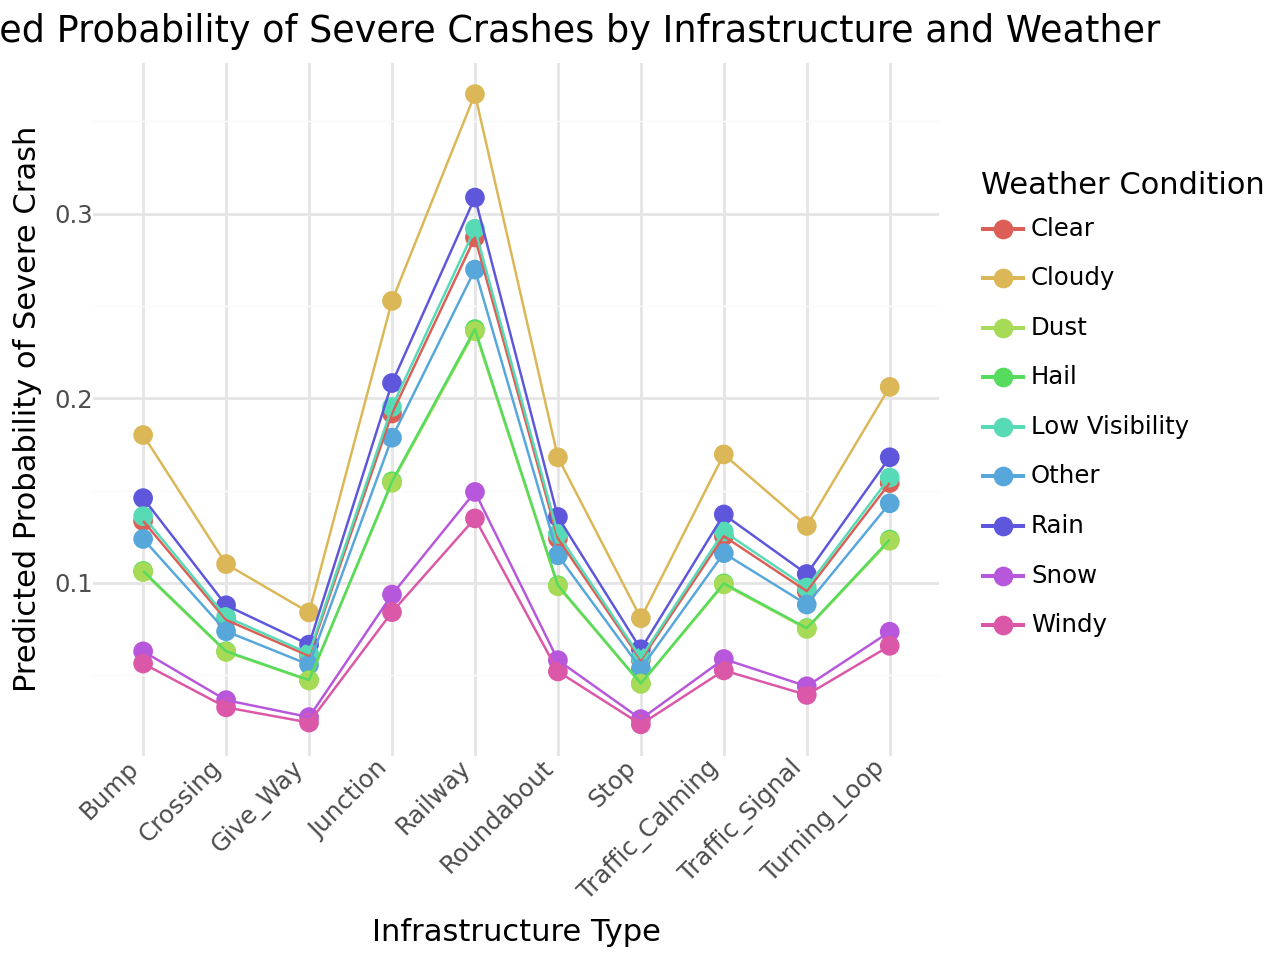

In [ ]:
from plotnine import *

(
    ggplot(combo_df,
           aes(x = "Infrastructure",
               y = "Predicted_Severity_Risk",
               color = "Weather_Group",
               group = "Weather_Group"))
    + geom_point()
    + geom_line()
    + labs(title = "Predicted Probability of Severe Crashes based on Infrastructure and Weather",
        x = "Infrastructure Type",
        y = "Predicted Probability of Severe Crash",
        color = "Weather Condition"
    )
    + theme_minimal()
    + theme(axis_text_x=element_text(rotation = 45, ha = "right"))
)

In [ ]:
#Secondary question
pipeline_secondary = make_pipeline(
    make_column_transformer(
        (StandardScaler(), []),
        remainder="passthrough"
    ),
    LogisticRegression(penalty=None)
)
df_sample = df.sample(500000, random_state=1)

pipeline_secondary.fit(df_sample[infra_features], df_sample["Severe"])

coefs = pipeline_secondary.named_steps["logisticregression"].coef_[0]

coef_df = pd.DataFrame({
    "feature": infra_features,
    "coefficient": coefs
}).sort_values("coefficient", ascending=False)

coef_df

,feature,coefficient
4,Railway,0.796524
3,Junction,0.272612
9,Turning_Loop,0.000000
5,Roundabout,-0.017101
0,Bump,-0.065068
8,Traffic_Calming,-0.078307
2,Give_Way,-0.203138
7,Traffic_Signal,-0.529414
1,Crossing,-0.753694
6,Stop,-1.092226


In [ ]:

infra_cols = [
    "Bump","Crossing","Give_Way","Junction","Railway",
    "Roundabout","Stop","Traffic_Signal","Traffic_Calming","Turning_Loop"
]

infra_severity = []

for col in infra_cols:
    severe_rate = df_sample[df_sample[col] == 1]["Severe"].mean()
    infra_severity.append({
        "Infrastructure": col,
        "Severe_Rate": severe_rate
    })

infra_severity = pd.DataFrame(infra_severity)
infra_severity



,Infrastructure,Severe_Rate
0,Bump,0.093248
1,Crossing,0.067979
2,Give_Way,0.024465
3,Junction,0.209935
4,Railway,0.229770
5,Roundabout,0.000000
6,Stop,0.055894
7,Traffic_Signal,0.087399
8,Traffic_Calming,0.085973
9,Turning_Loop,NaN


/usr/local/lib/python3.12/dist-packages/plotnine/layer.py:344: PlotnineWarning: position_stack : Removed 1 rows containing missing values.


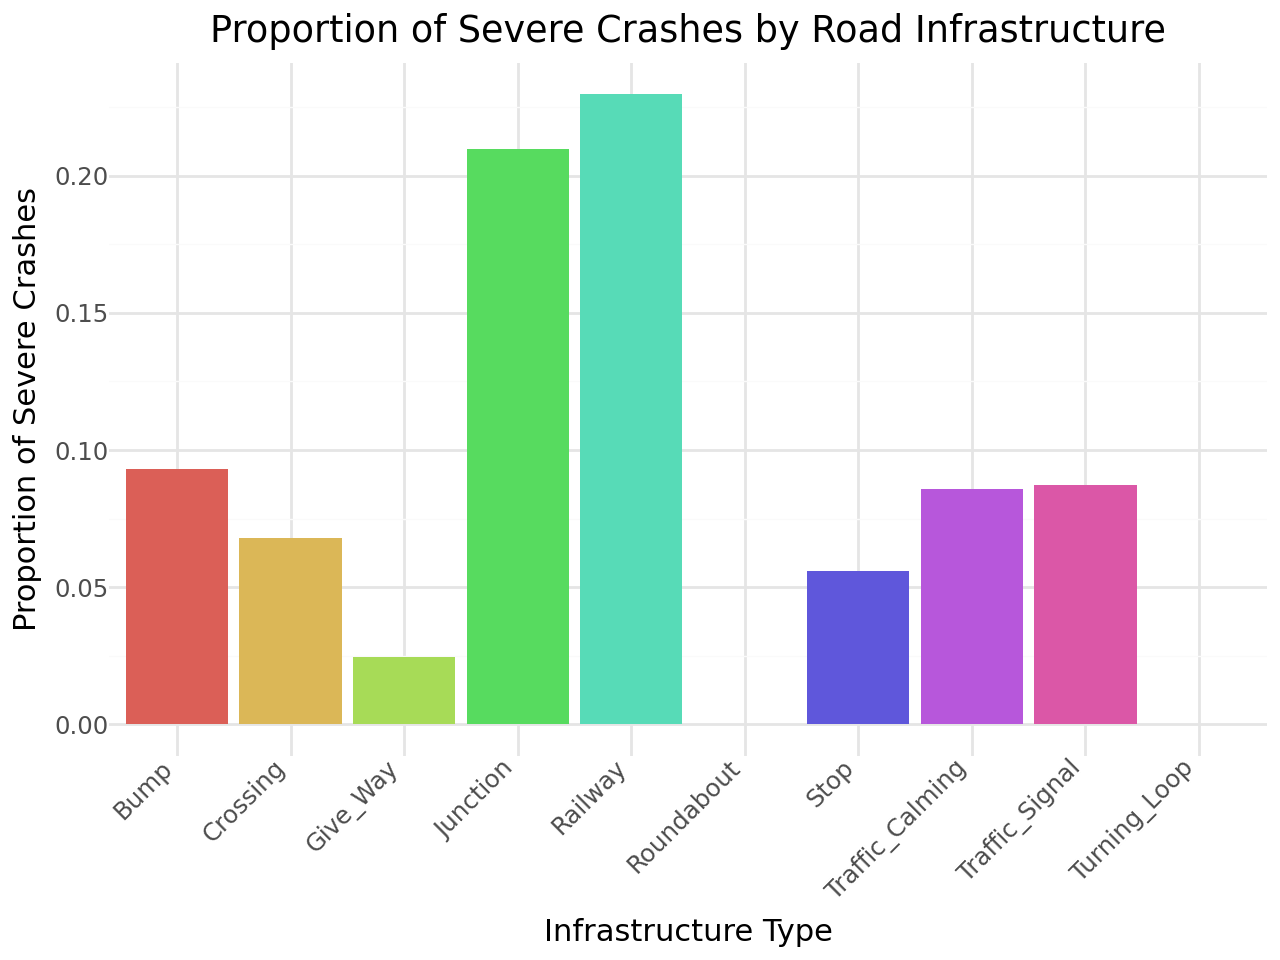

In [ ]:

(
    ggplot(infra_severity,
           aes(x = "Infrastructure",
               y = "Severe_Rate",
               fill = "Infrastructure"))
    + geom_col()
    + labs(
        title = "Proportion of Severe Crashes by Road Infrastructure",
        x = "Infrastructure Type",
        y = "Proportion of Severe Crashes"
    )
    + theme_minimal()
    + theme(axis_text_x = element_text(rotation = 45, ha = "right"),
            legend_position = "none")
)